<a href="https://colab.research.google.com/github/williamfaraday123/SC4001-Neural-Network/blob/main/Lim_Isaac_PartA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# 1. Load and Preprocess Data
# Note: Ensure 'simplified.csv' is uploaded to your Colab environment
df = pd.read_csv('https://raw.githubusercontent.com/williamfaraday123/SC4001-Neural-Network/refs/heads/main/simplified.csv')


In [3]:
# Extract labels from 'filename'. Assuming filename contains 'positive' or 'negative'
# Or if the filename itself is the label, we encode it.
# Adjust the lambda function below based on how your CSV represents labels.
df['label'] = df['filename'].apply(lambda x: 1 if 'pos' in x.lower() else 0)

X = df.drop(columns=['filename', 'label']).values
y = df['label'].values

# Split dataset (75:25)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scaling features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create DataLoaders
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [4]:
# 2. Define the DNN Architecture
class PolarityDNN(nn.Module):
    def __init__(self, input_dim):
        super(PolarityDNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
model = PolarityDNN(input_dim)


In [5]:
# 3. Optimizer and Loss
# Weight decay is represented by the 'weight_decay' parameter in Adam
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0005)
criterion = nn.BCELoss()

# 4. Training Loop with Early Stopping
epochs = 200
patience = 5
best_loss = np.inf
counter = 0

history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(epochs):
    model.train()
    train_losses = []
    correct_train = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        preds = (outputs > 0.5).float()
        correct_train += (preds == batch_y).sum().item()

    # Evaluation
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        test_loss = criterion(test_outputs, y_test_t).item()
        test_preds = (test_outputs > 0.5).float()
        test_acc = (test_preds == y_test_t).sum().item() / len(y_test)

    train_loss = np.mean(train_losses)
    train_acc = correct_train / len(y_train)

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    # Early Stopping Logic
    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
        # Optional: Save best model here
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break



Epoch 1/200 - Train Loss: 0.6881, Test Loss: 0.6810, Test Acc: 0.5685
Epoch 2/200 - Train Loss: 0.6769, Test Loss: 0.6657, Test Acc: 0.6060
Epoch 3/200 - Train Loss: 0.6663, Test Loss: 0.6557, Test Acc: 0.6199
Epoch 4/200 - Train Loss: 0.6560, Test Loss: 0.6464, Test Acc: 0.6275
Epoch 5/200 - Train Loss: 0.6455, Test Loss: 0.6372, Test Acc: 0.6415
Epoch 6/200 - Train Loss: 0.6354, Test Loss: 0.6295, Test Acc: 0.6507
Epoch 7/200 - Train Loss: 0.6232, Test Loss: 0.6215, Test Acc: 0.6531
Epoch 8/200 - Train Loss: 0.6168, Test Loss: 0.6126, Test Acc: 0.6660
Epoch 9/200 - Train Loss: 0.6027, Test Loss: 0.6039, Test Acc: 0.6806
Epoch 10/200 - Train Loss: 0.5977, Test Loss: 0.5997, Test Acc: 0.6799
Epoch 11/200 - Train Loss: 0.5907, Test Loss: 0.5906, Test Acc: 0.6829
Epoch 12/200 - Train Loss: 0.5803, Test Loss: 0.5898, Test Acc: 0.6839
Epoch 13/200 - Train Loss: 0.5728, Test Loss: 0.5817, Test Acc: 0.6972
Epoch 14/200 - Train Loss: 0.5657, Test Loss: 0.5759, Test Acc: 0.6942
Epoch 15/200 - 

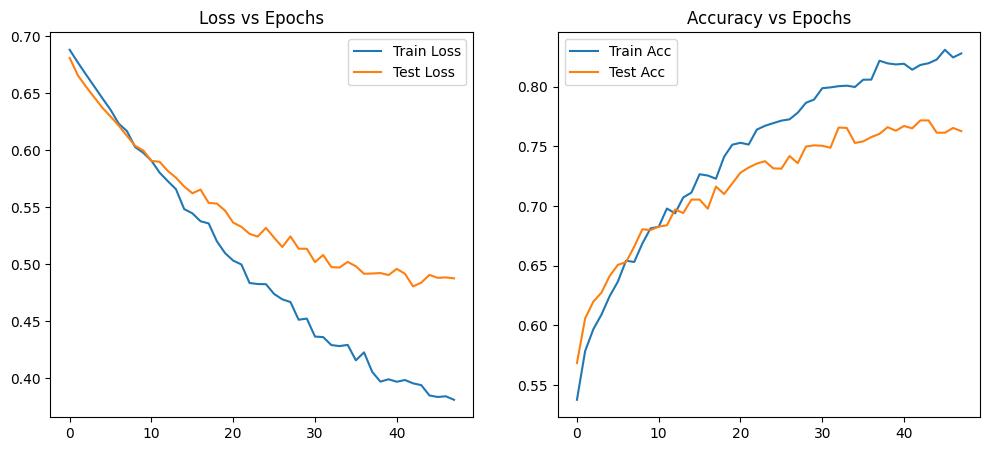

In [7]:
# 5. Plotting Results
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()